In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from PIL import Image
import ast
import os
import cv2
from tqdm import tqdm

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
train_data = pd.read_csv("/kaggle/input/ranzcr-clip-catheter-line-classification/train.csv")
train_data

,StudyInstanceUID,ETT - Abnormal,ETT - Borderline,ETT - Normal,NGT - Abnormal,NGT - Borderline,NGT - Incompletely Imaged,NGT - Normal,CVC - Abnormal,CVC - Borderline,CVC - Normal,Swan Ganz Catheter Present,PatientID
0,1.2.826.0.1.3680043.8.498.26697628953273228189...,0,0,0,0,0,0,1,0,0,0,0,ec89415d1
1,1.2.826.0.1.3680043.8.498.46302891597398758759...,0,0,1,0,0,1,0,0,0,1,0,bf4c6da3c
2,1.2.826.0.1.3680043.8.498.23819260719748494858...,0,0,0,0,0,0,0,0,1,0,0,3fc1c97e5
3,1.2.826.0.1.3680043.8.498.68286643202323212801...,0,0,0,0,0,0,0,1,0,0,0,c31019814
4,1.2.826.0.1.3680043.8.498.10050203009225938259...,0,0,0,0,0,0,0,0,0,1,0,207685cd1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30078,1.2.826.0.1.3680043.8.498.74257566841157531124...,0,0,1,0,0,0,0,0,1,1,0,5b5b9ac30
30079,1.2.826.0.1.3680043.8.498.46510939987173529969...,0,0,0,0,0,0,0,0,0,1,0,7192404d8
30080,1.2.826.0.1.3680043.8.498.43173270582850645437...,0,0,1,0,0,1,0,1,0,1,0,d4d1b066d
30081,1.2.826.0.1.3680043.8.498.95092491950130838685...,0,0,0,0,0,0,0,0,1,0,0,01a6602b8


In [4]:
# CVC_train = train_data[["StudyInstanceUID","CVC - Abnormal", "CVC - Borderline", "CVC - Normal"]]
# CVC_train.set_index('StudyInstanceUID', inplace=True)
# CVC_train.head()


train_data = train_data[(train_data['NGT - Incompletely Imaged'] != 1) & (train_data['NGT - Borderline'] != 1 )]

train_data[['NGT - Normal', 'NGT - Abnormal', 'NGT - Borderline', 'NGT - Incompletely Imaged']].value_counts()
train_data['NGT - Present'] = np.where((train_data['NGT - Normal'] == 0) & (train_data['NGT - Abnormal'] == 0) & (train_data['NGT - Borderline'] == 0), 0, 1)

train_data[['NGT - Normal', 'NGT - Abnormal']].value_counts()
# train_data['CVC - Borderline'].value_counts()
# # train_data
# # train_data['CVC - Borderline'] = np.where((train_data['CVC - Normal'] == 1) | (train_data['CVC - Abnormal'] == 1), 0, 0)

# train_data['CVC - Present'] = np.where((train_data['CVC - Abnormal'] == 0) & (train_data['CVC - Normal'] == 0), 0, 1)

# train_data['CVC - Present'].value_counts()

/tmp/ipykernel_33/4014350276.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['NGT - Present'] = np.where((train_data['NGT - Normal'] == 0) & (train_data['NGT - Abnormal'] == 0) & (train_data['NGT - Borderline'] == 0), 0, 1)


NGT - Normal  NGT - Abnormal
0             0                 21775
1             0                  4768
0             1                   259
1             1                     9
Name: count, dtype: int64

In [5]:
normalAb = pd.concat([train_data[train_data['NGT - Normal'] == 1].sample(n=125), train_data[train_data['NGT - Abnormal'] == 1].sample(n=125)])
sampled_data = pd.concat([normalAb, train_data[train_data['NGT - Present'] == 0].sample(n=250)])

# sampled_data = pd.concat([train_data[train_data['CVC - Present'] == 1].sample(n=750), train_data[train_data['CVC - Present'] == 0].sample(n=750)])
sampled_data

,StudyInstanceUID,ETT - Abnormal,ETT - Borderline,ETT - Normal,NGT - Abnormal,NGT - Borderline,NGT - Incompletely Imaged,NGT - Normal,CVC - Abnormal,CVC - Borderline,CVC - Normal,Swan Ganz Catheter Present,PatientID,NGT - Present
16256,1.2.826.0.1.3680043.8.498.11776779129316586168...,0,1,0,0,0,0,1,0,1,0,0,71db74d9f,1
29026,1.2.826.0.1.3680043.8.498.12001520041092251570...,0,0,1,0,0,0,1,0,0,1,0,8260896cf,1
14102,1.2.826.0.1.3680043.8.498.42458175546267500980...,0,0,1,0,0,0,1,0,0,1,0,2bb41c720,1
14505,1.2.826.0.1.3680043.8.498.40433056263341380457...,0,0,1,0,0,0,1,0,1,1,0,c20ec34df,1
7790,1.2.826.0.1.3680043.8.498.10801648034728534499...,0,0,1,0,0,0,1,0,0,1,0,e8c275cb5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21937,1.2.826.0.1.3680043.8.498.69270613365707381714...,0,0,0,0,0,0,0,0,1,0,0,6e5ddf472,0
28341,1.2.826.0.1.3680043.8.498.10725157893852568257...,0,0,0,0,0,0,0,0,0,1,0,5b46c2b94,0
18705,1.2.826.0.1.3680043.8.498.64664374691459645415...,0,0,0,0,0,0,0,0,1,0,0,1ae0167a7,0
24453,1.2.826.0.1.3680043.8.498.58143509546923965987...,0,0,0,0,0,0,0,0,1,0,0,871190b8e,0


In [6]:
def getFileNames(df):
    studyInstance = df['StudyInstanceUID'].tolist()
    studyInstance

    for i in range(len(studyInstance)):
        studyInstance[i] = f'{studyInstance[i]}.jpg'
      
    return studyInstance
    

In [7]:
studyInstance = getFileNames(sampled_data)

In [8]:
def processImages(filenames,train_test):

    imgs = []
    FileIDs = []
    lst = []


    desired_channels = 3

    count = 0
    for file in tqdm(filenames, position=0, leave=True):
        # Making sure the images are the same pixel size
        img = Image.open(f"/kaggle/input/ranzcr-clip-catheter-line-classification/{train_test}/{file}")
        img = img.resize((300, 300))
        img = np.array(img)

        # Ensure that the image has 3 channels (RGB)
        if img.shape[-1] != 3:
            img = np.stack((img,) * 3, axis=-1)  # Convert grayscale to RGB by duplicating channels

        imgs.append(img)  # Append the 4D image to the list

        # Save filename for later
        FileIDs.append(file)

        count += 1

    # Convert the list of images to a numpy array
    imgs = np.array(imgs)
    return imgs, FileIDs

In [9]:
train_imgs, fileIDs = processImages(studyInstance, 'train')

100%|██████████| 500/500 [00:27<00:00, 18.32it/s]


In [10]:
#cleaning up the labels
UID = []
for i in range(len(fileIDs)):
  UID.append(fileIDs[i].replace(".jpg",""))

UID[0:10]

['1.2.826.0.1.3680043.8.498.11776779129316586168256760908844163643',
 '1.2.826.0.1.3680043.8.498.12001520041092251570047083277826578004',
 '1.2.826.0.1.3680043.8.498.42458175546267500980938096810058107305',
 '1.2.826.0.1.3680043.8.498.40433056263341380457168780222178947107',
 '1.2.826.0.1.3680043.8.498.10801648034728534499146042439437500265',
 '1.2.826.0.1.3680043.8.498.26651124752164857586659319428477751174',
 '1.2.826.0.1.3680043.8.498.83196869551709445153844607778602174536',
 '1.2.826.0.1.3680043.8.498.11020960047173957279476363200559768560',
 '1.2.826.0.1.3680043.8.498.58533787466993692760531776031388954558',
 '1.2.826.0.1.3680043.8.498.46258285496547538555902691951499777219']

In [11]:
columns_to_drop = ['ETT - Abnormal', 'ETT - Borderline', 'ETT - Normal', 'NGT - Abnormal', 'NGT - Borderline', 'NGT - Normal',
                  "NGT - Incompletely Imaged", "Swan Ganz Catheter Present", "PatientID", "CVC - Borderline", 'CVC - Abnormal', 'CVC - Normal']

NGTsampled_data = sampled_data.drop(columns=columns_to_drop, axis=1)

NGTsampled_data.set_index('StudyInstanceUID', inplace=True)

In [12]:
train_labels_df = np.empty((0,3))
data = []

for ID in UID:
    data.append(NGTsampled_data.loc[ID])

train_labels_df = pd.DataFrame(data)



train_labels_df = train_labels_df.reindex(UID)
train_labels = train_labels_df['NGT - Present'].values
# train_labels = train_labels_df.values
train_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [13]:
from sklearn.model_selection import train_test_split

# Split your data into training and temporary data (combined validation and test)
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(train_imgs, train_labels, test_size=0.2, random_state=42)

# Split the temporary data into validation and test sets
val_imgs, test_imgs, val_labels, test_labels = train_test_split(temp_imgs, temp_labels, test_size=0.5, random_state=42)

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# CVC Detection

In [15]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.models import Model


# from tensorflow.keras.layers import Dropout, BatchNormalization

# # Data Preparation
# # Load and preprocess your image data and labels here.

# # Load the ResNet50 model with pre-trained weights
# base_model = ResNet50(weights='imagenet', include_top=False)


# # Add dropout and batch normalization to custom fully connected layers
# x = base_model.output
# x = GlobalAveragePooling2D()(x)
# x = Dense(1024, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.5)(x)
# predictions = Dense(1, activation='sigmoid')(x)
# model = Model(inputs=base_model.input, outputs=predictions)

In [16]:
# from tensorflow.keras.callbacks import ReduceLROnPlateau
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# # Reduce learning rate when the validation loss plateaus
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# # Compile the model with optimizer and loss function
# model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

# # Early stopping to prevent overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Save the best model during training
# model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)

# # Model Training with callbacks
# history = model.fit(train_imgs, train_labels, epochs=30, validation_data=(val_imgs, val_labels), callbacks=[reduce_lr, early_stop, model_checkpoint])

# # Evaluate the model
# test_loss, test_accuracy = model.evaluate(test_imgs, test_labels)
# print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

In [17]:
# # Make predictions
# predictions = model.predict(test_imgs)

# # Convert the predictions to a binary array
# predictions_binary = np.where(predictions > 0.5, 1, 0)

In [18]:
# from sklearn.metrics import confusion_matrix

# # Create the confusion matrix
# confusion_matrix = confusion_matrix(test_labels, predictions_binary)

In [19]:
# confusion_matrix


# plt.gca().patch.set_facecolor('none')



# custom_palette = ['#D3E0EA', '#AAB8C4', '#8498A2', '#5D7D88', '#3C6270', 
#                   '#1F465E', '#132D4B', '#0A1C36', '#051024', '#020916']

# # Create a heatmap plot of the confusion matrix
# sns.heatmap(confusion_matrix, annot=True, cmap=custom_palette)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()


# plt.savefig('confusionmatrix_CVCexistence.png', bbox_inches='tight', transparent=True)

# NORMAL OR ABNORMAL

In [20]:
def buildTrainData(catheter, train_data, size):
    
    train_data = train_data[train_data[f'{catheter} - Present'] == 1]
    train_data = train_data = train_data[~((train_data[f'{catheter} - Normal'] == 1) & (train_data[f'{catheter} - Abnormal'] == 1))]
    train_data[f'{catheter} - Normal/Abnormal'] = np.where(train_data[f'{catheter} - Normal'] == 1, 1, 0)
    sampled_data = pd.concat([train_data[train_data[f'{catheter} - Normal'] == 1].sample(n=size), train_data[train_data[f'{catheter} - Abnormal'] == 1].sample(n=size)])
    
    return sampled_data
    

In [21]:
sample = buildTrainData('NGT', train_data, 250)
sample

,StudyInstanceUID,ETT - Abnormal,ETT - Borderline,ETT - Normal,NGT - Abnormal,NGT - Borderline,NGT - Incompletely Imaged,NGT - Normal,CVC - Abnormal,CVC - Borderline,CVC - Normal,Swan Ganz Catheter Present,PatientID,NGT - Present,NGT - Normal/Abnormal
3362,1.2.826.0.1.3680043.8.498.57331265500266781726...,0,0,1,0,0,0,1,0,1,0,0,6a9587778,1,1
24671,1.2.826.0.1.3680043.8.498.84211592801291898349...,0,0,0,0,0,0,1,0,0,1,0,ffb6ebe51,1,1
25599,1.2.826.0.1.3680043.8.498.35772244095675958072...,0,0,0,0,0,0,1,1,0,0,0,97389d001,1,1
6472,1.2.826.0.1.3680043.8.498.68185419571858956257...,0,0,1,0,0,0,1,0,0,1,0,2bb41c720,1,1
28437,1.2.826.0.1.3680043.8.498.44392853707264216886...,0,0,1,0,0,0,1,0,0,1,0,2bb41c720,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10129,1.2.826.0.1.3680043.8.498.49649080131372703362...,0,0,1,1,0,0,0,0,1,0,0,e8bd2e98f,1,0
14132,1.2.826.0.1.3680043.8.498.41046293714585303525...,0,0,1,1,0,0,0,1,0,0,0,e7db14fce,1,0
27154,1.2.826.0.1.3680043.8.498.80031217684058635464...,0,0,1,1,0,0,0,0,0,1,0,46980450c,1,0
7009,1.2.826.0.1.3680043.8.498.98472838905910224876...,0,0,0,1,0,0,0,0,0,1,0,a5771279d,1,0


In [22]:
nAb_data = getFileNames(sample)

ngt_imgs, fileIDs = processImages(nAb_data, 'train')

100%|██████████| 500/500 [00:25<00:00, 19.82it/s]


In [23]:
UID = []
for i in range(len(fileIDs)):
  UID.append(fileIDs[i].replace(".jpg",""))


columns_to_drop = ['ETT - Abnormal', 'ETT - Borderline', 'ETT - Normal', 'NGT - Abnormal', 'NGT - Borderline', 'NGT - Normal',
                  "NGT - Incompletely Imaged", "Swan Ganz Catheter Present", "PatientID", "CVC - Borderline", 'CVC - Abnormal', 'CVC - Normal', 'NGT - Present']

NGTsample = sample.drop(columns=columns_to_drop, axis=1)

NGTsample.set_index('StudyInstanceUID', inplace=True)

NGTsample

,NGT - Normal/Abnormal
StudyInstanceUID,
1.2.826.0.1.3680043.8.498.57331265500266781726245719857788142177,1
1.2.826.0.1.3680043.8.498.84211592801291898349508419619509147485,1
1.2.826.0.1.3680043.8.498.35772244095675958072394978496245125294,1
1.2.826.0.1.3680043.8.498.68185419571858956257615887592533591068,1
1.2.826.0.1.3680043.8.498.44392853707264216886847752497626525031,1
...,...
1.2.826.0.1.3680043.8.498.49649080131372703362614775551931976912,0
1.2.826.0.1.3680043.8.498.41046293714585303525344264258100057358,0
1.2.826.0.1.3680043.8.498.80031217684058635464556714012970291792,0


In [24]:
train_labels_df = np.empty((0,3))
data = []

for ID in UID:
    data.append(NGTsample.loc[ID])

train_labels_df = pd.DataFrame(data)



train_labels_df = train_labels_df.reindex(UID)
ngt_labels = train_labels_df['NGT - Normal/Abnormal'].values
# train_labels = train_labels_df.values
ngt_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [25]:
from sklearn.model_selection import train_test_split

# Split your data into training and temporary data (combined validation and test)
trainNGT_imgs, temp_imgs, trainNGT_labels, temp_labels = train_test_split(ngt_imgs, ngt_labels, test_size=0.2, random_state=42)

# Split the temporary data into validation and test sets
valNGT_imgs, testNGT_imgs, valNGT_labels, testNGT_labels = train_test_split(temp_imgs, temp_labels, test_size=0.5, random_state=42)

In [26]:
# Load the ResNet50 model with pre-trained weights
# base_model = ResNet50(weights='imagenet', include_top=False) ## If we get rid of this, does it add this model to the previous model? IDK 


# # Add dropout and batch normalization to custom fully connected layers
# x = base_model.output
# x = GlobalAveragePooling2D()(x)
# x = Dense(1024, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.5)(x)
# predictions = Dense(1, activation='sigmoid')(x)
# model = Model(inputs=base_model.input, outputs=predictions)

# # Reduce learning rate when the validation loss plateaus
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# # Compile the model with optimizer and loss function
# model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

# # Early stopping to prevent overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Save the best model during training
# model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)

# # Model Training with callbacks
# history = model.fit(trainCVC_imgs, trainCVC_labels, epochs=30, validation_data=(val_imgs, val_labels), callbacks=[reduce_lr, early_stop, model_checkpoint])

# # Evaluate the model
# test_loss, test_accuracy = model.evaluate(testCVC_imgs, testCVC_labels)
# print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

In [27]:
# # Make predictions
# predictions = model.predict(test_imgs)

# # Convert the predictions to a binary array
# predictions_binary = np.where(predictions > 0.5, 1, 0)


# from sklearn.metrics import confusion_matrix

# # Create the confusion matrix
# confusion_matrix = confusion_matrix(test_labels, predictions_binary)

# plt.gca().patch.set_facecolor('none')



# custom_palette = ['#D3E0EA', '#AAB8C4', '#8498A2', '#5D7D88', '#3C6270', 
#                   '#1F465E', '#132D4B', '#0A1C36', '#051024', '#020916']

# # Create a heatmap plot of the confusion matrix
# sns.heatmap(confusion_matrix, annot=True, cmap=custom_palette)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()


# plt.savefig('confusionmatrix_CVCexistence.png', bbox_inches='tight', transparent=True)



In [28]:
len(train_labels)

400

In [29]:
from tensorflow.keras.layers import concatenate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model


from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load the ResNet50 model with pre-trained weights
base_model = ResNet50(weights='imagenet', include_top=False)

# Add dropout and batch normalization to custom fully connected layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# First Output Branch: CVC Catheter Presence (Binary Classification)
output_CVCpresent = Dense(1, activation='sigmoid', name='output_NGTpresent')(x)

# Add a separate set of layers for the new task
y = base_model.output
y = GlobalAveragePooling2D()(y)
y = Dense(1024, activation='relu')(y)
y = BatchNormalization()(y)
y = Dropout(0.5)(y)

# Second Output Branch: CVC Placement (Binary Classification)
output_cvc_placement = Dense(1, activation='sigmoid', name='output_NGTnormalAbnormal')(y)

# Combine the two output branches
combined_model = Model(inputs=base_model.input, outputs=[output_CVCpresent, output_cvc_placement])

# Compile the combined model with optimizer and loss functions for both tasks
combined_model.compile(optimizer='SGD', 
                       loss={'output_NGTpresent': 'binary_crossentropy', 'output_NGTnormalAbnormal': 'binary_crossentropy'}, 
                       metrics={'output_NGTpresent': 'accuracy', 'output_NGTnormalAbnormal': 'accuracy'})

# # Reduce learning rate when the validation loss plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Save the best model during training
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)

history = combined_model.fit(
    {'input_1': train_imgs},
    {'output_NGTpresent': train_labels, 'output_NGTnormalAbnormal': trainNGT_labels},
    epochs=30,
    validation_data=(
        {'input_1': val_imgs},
        {'output_NGTpresent': val_labels, 'output_NGTnormalAbnormal': valNGT_labels}
    ),
    callbacks=[reduce_lr, early_stop, model_checkpoint]
)

# # Evaluate the combined model
# test_loss, [test_accuracy_catheter, test_accuracy_cvc_placement] = combined_model.evaluate(
#     {'input_1': test_imgs},
#     {'output_catheter': test_labels, 'output_cvc_placement': testCVC_labels}
# )

# print(f'Test Accuracy (Catheter): {test_accuracy_catheter * 100:.2f}%')
# print(f'Test Accuracy (CVC Placement): {test_accuracy_cvc_placement * 100:.2f}%')

94765736/94765736 [==============================] - 0s 0us/step
Epoch 1/30
13/13 [==============================] - 35s 703ms/step - loss: 1.3631 - output_NGTpresent_loss: 0.6980 - output_NGTnormalAbnormal_loss: 0.6651 - output_NGTpresent_accuracy: 0.6750 - output_NGTnormalAbnormal_accuracy: 0.6800 - val_loss: 1.6005 - val_output_NGTpresent_loss: 0.8239 - val_output_NGTnormalAbnormal_loss: 0.7766 - val_output_NGTpresent_accuracy: 0.4600 - val_output_NGTnormalAbnormal_accuracy: 0.4800 - lr: 0.0100
Epoch 2/30
13/13 [==============================] - 5s 384ms/step - loss: 0.7763 - output_NGTpresent_loss: 0.3906 - output_NGTnormalAbnormal_loss: 0.3857 - output_NGTpresent_accuracy: 0.8300 - output_NGTnormalAbnormal_accuracy: 0.8275 - val_loss: 1.5142 - val_output_NGTpresent_loss: 0.7921 - val_output_NGTnormalAbnormal_loss: 0.7222 - val_output_NGTpresent_accuracy: 0.4600 - val_output_NGTnormalAbnormal_accuracy: 0.4800 - lr: 0.0100
Epoch 3/30
13/13 [==============================] - 5s 419ms

In [31]:
# Evaluate accuracy for the 'output_catheter' branch
evaluation = combined_model.evaluate(
    {'input_1': test_imgs},
    {'output_NGTpresent': test_labels, 'output_NGTnormalAbnormal': testNGT_labels},
)

# Extract the accuracy values from the evaluation results
test_accuracy_catheter = evaluation[3]  # Index 3 corresponds to 'output_catheter_accuracy'
test_accuracy_cvc_placement = evaluation[4]  # Index 4 corresponds to 'output_cvc_placement_accuracy'

print(f'Test Accuracy (NGT Present): {test_accuracy_catheter * 100:.2f}%')
print(f'Test Accuracy (NGT Normal/Abnormal): {test_accuracy_cvc_placement * 100:.2f}%')


2/2 [==============================] - 0s 69ms/step - loss: 1.1829 - output_NGTpresent_loss: 0.5949 - output_NGTnormalAbnormal_loss: 0.5880 - output_NGTpresent_accuracy: 0.6400 - output_NGTnormalAbnormal_accuracy: 0.6800
Test Accuracy (NGT Present): 64.00%
Test Accuracy (NGT Normal/Abnormal): 68.00%


2/2 [==============================] - 0s 91ms/step


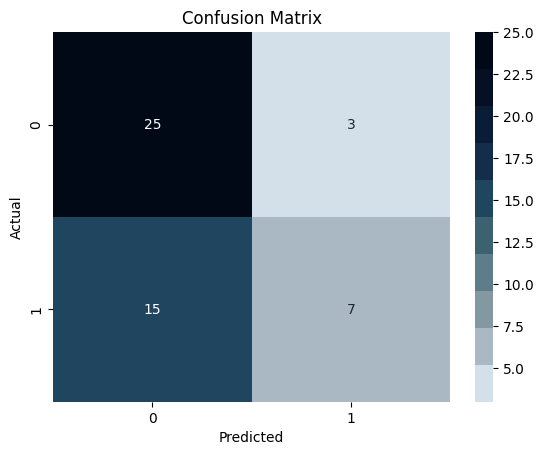

<Figure size 640x480 with 0 Axes>

In [34]:
# Make predictions
predictions = combined_model.predict(test_imgs)
predictions

# Access predictions for the first task
ngt_present_predictions = predictions[0]
ngt_present_predictions
# Access predictions for the second task
ngt_normal_abnormal_predictions = predictions[1]

ngt_present_predictions
# Create two separate DataFrames
df1 = pd.DataFrame(ngt_present_predictions, columns=["NGT - Present"])
df2 = pd.DataFrame(ngt_normal_abnormal_predictions, columns=['NGT - Normal/Abnormal'])

# # Concatenate the DataFrames horizontally to create one with two columns
NGTpredictions = pd.concat([df1, df2], axis=1)
NGTpredictions

NGTpredictions['NGT - Present'] = np.where(NGTpredictions['NGT - Present'] > 0.5, 1, 0)
NGTpredictions['NGT - Normal/Abnormal'] = np.where(NGTpredictions['NGT - Normal/Abnormal'] > 0.5, 1, 0)
NGTpredictions

from sklearn.metrics import confusion_matrix

# Create the confusion matrix
confusion_matrix_present = confusion_matrix(test_labels, NGTpredictions['NGT - Present'])

plt.gca().patch.set_facecolor('none')



custom_palette = ['#D3E0EA', '#AAB8C4', '#8498A2', '#5D7D88', '#3C6270', 
                  '#1F465E', '#132D4B', '#0A1C36', '#051024', '#020916']

# Create a heatmap plot of the confusion matrix
sns.heatmap(confusion_matrix_present, annot=True, cmap=custom_palette)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


plt.savefig('confusionmatrix_NGTexistence.png', bbox_inches='tight', transparent=True)


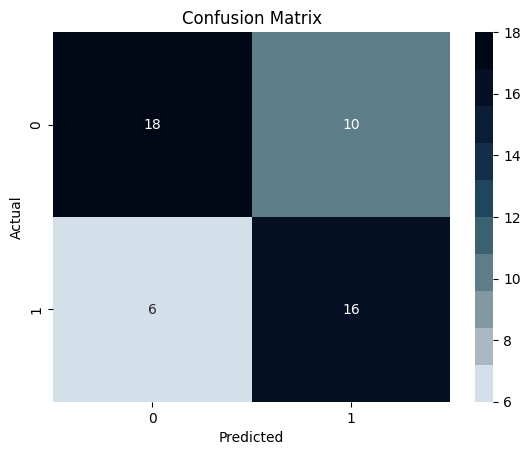

In [35]:
from sklearn.metrics import confusion_matrix
confusion_matrix_normal = confusion_matrix(testNGT_labels, NGTpredictions['NGT - Normal/Abnormal'])

plt.gca().patch.set_facecolor('none')



custom_palette = ['#D3E0EA', '#AAB8C4', '#8498A2', '#5D7D88', '#3C6270', 
                  '#1F465E', '#132D4B', '#0A1C36', '#051024', '#020916']

# Create a heatmap plot of the confusion matrix
sns.heatmap(confusion_matrix_normal, annot=True, cmap=custom_palette)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# plt.savefig('confusionmatrix_CVCexistence.png', bbox_inches='tight', transparent=True)

In [ ]:
history.history

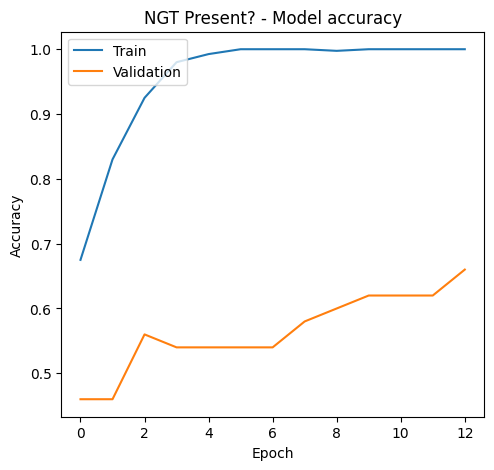

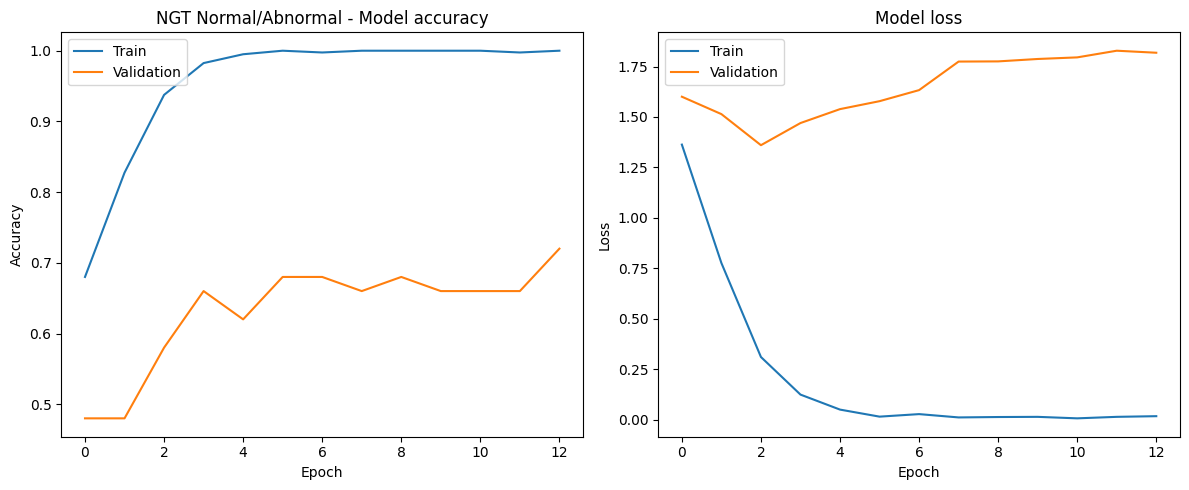

In [36]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['output_NGTpresent_accuracy'])
plt.plot(history.history['val_output_NGTpresent_accuracy'])
plt.title('NGT Present? - Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['output_NGTnormalAbnormal_accuracy'])
plt.plot(history.history['val_output_NGTnormalAbnormal_accuracy'])
plt.title('NGT Normal/Abnormal - Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')


# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()